# 딥러닝의 기본 이미지 분류

### 1. 데이터셋

In [33]:
import os
from pathlib import Path
import random


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch
from torch import nn,optim
from torchvision import datasets, models
import torchvision.transforms.v2 as transforms
from torchvision.utils import make_grid
from torch.utils.data import DataLoader
from collections import OrderedDict
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

seed = 1010
random.seed(seed)         # python seed
np.random.seed(seed)      # numpy seed
torch.manual_seed(seed)   # torch seed


cpu


In [34]:

print("Train")
print("NORMAL:", len(os.listdir("data/chest_xray/train/NORMAL")), end=', ')
print("PNEUMONIA:", len(os.listdir("data/chest_xray/train/PNEUMONIA")))
print()
print("Validation")
print("NORMAL:", len(os.listdir("data/chest_xray/val/NORMAL")), end=', ')
print("PNEUMONIA:", len(os.listdir("data/chest_xray/val/PNEUMONIA")))
print()
print("Test")
print("NORMAL:", len(os.listdir("data/chest_xray/test/NORMAL")), end=', ')
print("PNEUMONIA:", len(os.listdir("data/chest_xray/test/PNEUMONIA")))

Train
NORMAL: 1342, PNEUMONIA: 3876

Validation
NORMAL: 9, PNEUMONIA: 9

Test
NORMAL: 234, PNEUMONIA: 390


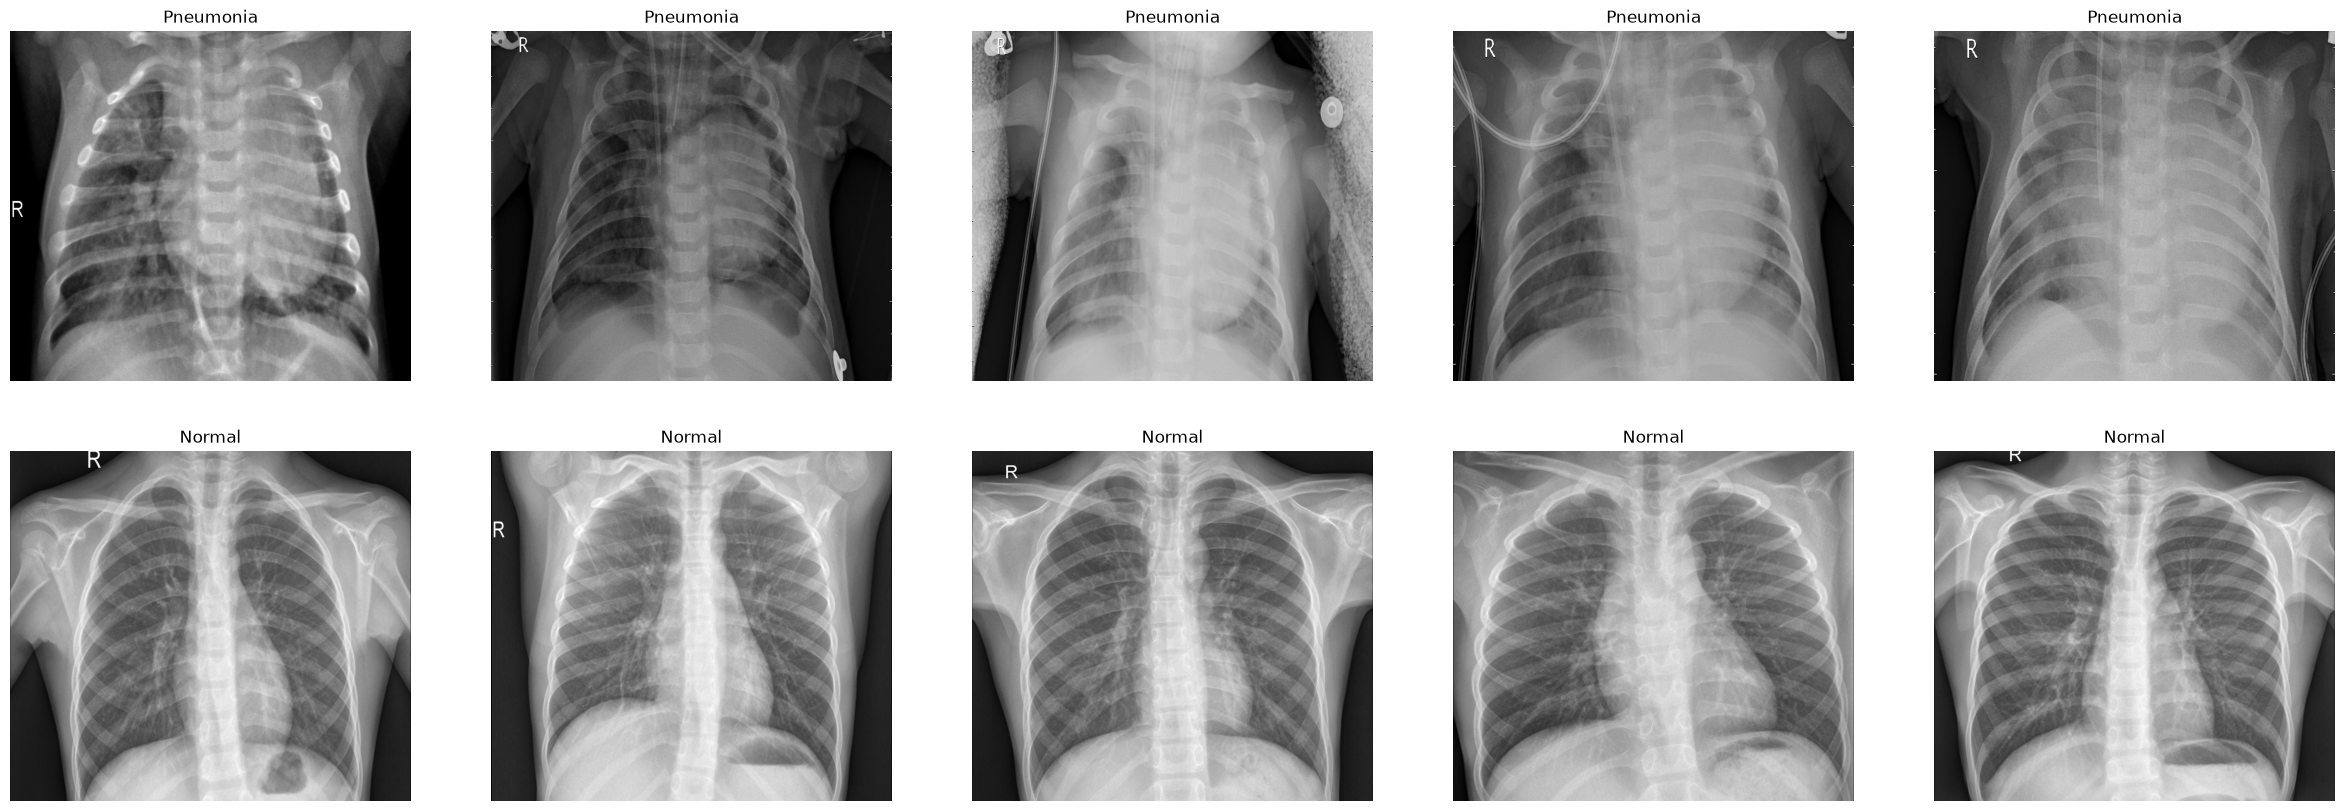

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

root = "data/chest_xray/test/"
normal_dir = root + 'NORMAL/'
pneumonia_dir = root + 'PNEUMONIA/'

normal = list(map(lambda x: normal_dir+x, os.listdir(normal_dir)[:5]))
pneumonia = list(map(lambda x: pneumonia_dir+x, os.listdir(pneumonia_dir)[:5]))

samples = pneumonia + normal

# show samples
plt.figure(figsize=(30,10))
for i in range(10):
  plt.subplot(2, 5, i+1)
  img = Image.open(samples[i])

  ax = plt.gca()
  ax.set_title("Pneumonia" if i < 5 else "Normal")
  ax.imshow(img, cmap='gray')
  ax.axis('off')
  ax.set_aspect('auto')
plt.show()

In [36]:
print(dir(trainset.dataset))

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_format_transform_repr', '_repr_indent', 'class_to_idx', 'classes', 'extensions', 'extra_repr', 'find_classes', 'imgs', 'loader', 'make_dataset', 'root', 'samples', 'target_transform', 'targets', 'transform', 'transforms']


In [37]:
image, label = trainset[0]

print(image.shape)
print(label)

torch.Size([3, 224, 224])
1


In [38]:
def get_dataset(
    root="data/chest_xray", val=0.1,
    train_transforms=None, test_transforms=None
):
  origin = datasets.ImageFolder(
      os.path.join(root, 'train'),
      transform=train_transforms
  )

  val_samples = int(len(origin) * val)
  train_samples = len(origin) - val_samples

  trainset, valset = torch.utils.data.random_split(
    origin,
    (train_samples, val_samples),
  )
  valset.transforms = test_transforms

  testset = datasets.ImageFolder(
      os.path.join(root, 'test'),
      transform=test_transforms
  )
  return trainset, valset, testset

trainset, valset, testset = get_dataset(train_transforms=transforms.ToTensor())
print(len(trainset), len(valset), len(testset))

4695 521 624


In [39]:
class_names = trainset.dataset.classes
print(class_names)
print(trainset.dataset.class_to_idx)

['NORMAL', 'PNEUMONIA']
{'NORMAL': 0, 'PNEUMONIA': 1}


# 2. 데이터 증강과 Albumentation

In [40]:
import cv2
from torchvision.datasets import ImageFolder
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [41]:
train_transform = transforms.Compose([
    # 1. 원본 이미지의 크기를 256x256 픽셀로 조정 (해상도 통일)
    transforms.Resize((256, 256)),
    
    # 2. -20도에서 +20도 사이의 임의의 각도로 이미지를 무작위 회전 (데이터 증강)
    # * X-ray 특성상 환자가 미세하게 기울어져 촬영된 상황을 시뮬레이션하는 효과가 있습니다.
    transforms.RandomRotation(degrees=(-20, +20)),
    
    # 3. 256x256 크기로 커진 이미지에서 무작위로 224x224 영역을 잘라냄 (데이터 증강)
    # * 모델이 객체의 위치 변화에 둔감해지도록 유도하며, 최종 입력 크기를 224x224로 맞춥니다.
    transforms.RandomCrop((224, 224)),
    
    # 4. PIL 이미지나 NumPy 배열을 파이토치 텐서(Tensor)로 변환
    # * 이 과정에서 0~255 사이의 픽셀 값이 0.0~1.0의 실수 값으로 자동 정규화(Scaling)됩니다.
    transforms.ToTensor(),
    
    # 5. 첫 번째 인자(평균), 두 번째 인자(표준편차)를 사용해 데이터 정규화(Normalization)
    # * ImageNet 데이터셋의 통계치를 활용해 데이터 분포를 제로 센터링(Zero-centering)합니다.
    # * 이 정규화는 모델의 학습 속도를 높이고, 경사하강법(Gradient Descent)이 안정적으로 수렴하도록 돕습니다.
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


trainset, _, _ = get_dataset(
  train_transforms=train_transform,
)

train_loader = DataLoader(
  dataset=trainset,
  shuffle=True,
  batch_size=64,
  num_workers=0,
)

for i in tqdm(train_loader):
  pass


100%|██████████| 74/74 [01:33<00:00,  1.27s/it]


In [42]:
class AlbumentationsDataset(ImageFolder):

  def __getitem__(self, index: int):
    path, target = self.samples[index]
    # Read image
    image = cv2.imread(path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Transform
    if self.transform is not None:
      augmented = self.transform(image=image)
      image = augmented['image']

    return image, target

## Albumentation만의 특별한 기능

In [44]:
test_transform = A.Compose([
    # 1. 이미지를 256x256 크기로 리사이즈
    A.Resize(256, 256),

    # 2. 아래 3가지 기하학적 변환 중 '하나'를 100% 확률(p=1)로 선택하여 적용
    A.OneOf([
        A.HorizontalFlip(p=1),   # 좌우 반전
        A.RandomRotate90(p=1),   # 90도 단위 무작위 회전 (90°, 180°, 270°)
        A.VerticalFlip(p=1)      # 상하 반전
    ], p=1),

    # 3. 이미지의 중앙을 기준으로 224x224 크기로 잘라냄
    A.CenterCrop(224, 224),

    # 4. 아래 3가지 노이즈/왜곡 변환 중 '하나'를 50% 확률(p=0.5)로 선택하여 적용
    A.OneOf([
        A.MotionBlur(p=0.3),         # 피사체가 흔들린 듯한 모션 블러 효과
        A.OpticalDistortion(p=0.4),  # 카메라 렌즈 상의 광학 왜곡 효과
        A.GaussNoise(p=0.5)          # 가우시안 노이즈(노이즈 입자) 추가
    ], p=0.5),

    # 5. NumPy 배열(HWC 형식)을 PyTorch Tensor(CHW 형식)로 변환
    ToTensorV2(),
])

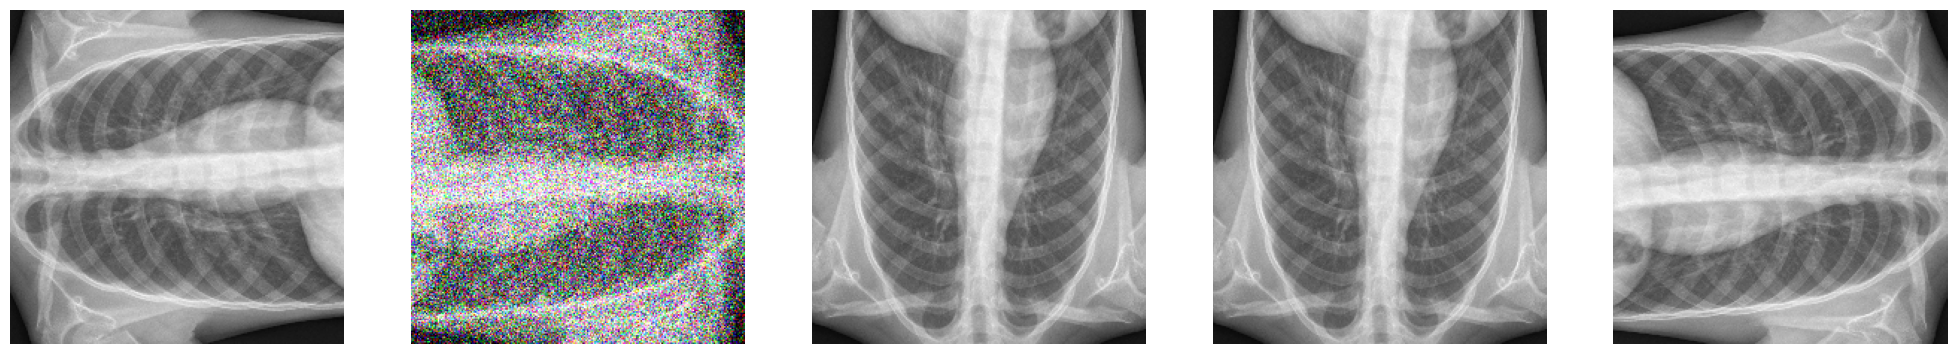

In [45]:
data_dir = Path("data/chest_xray/")
testset = AlbumentationsDataset(data_dir / 'test', transform=test_transform)

num_samples = 5
fig, ax = plt.subplots(1, num_samples, figsize=(25, 5))
for i in range(num_samples):
  ax[i].imshow(transforms.ToPILImage()(testset[0][0]))
  ax[i].axis('off')

# 학습

In [46]:
import torchvision.models as models
from torchvision.models.resnet import ResNet18_Weights

model = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta